# 1.라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 사이킷런 내장 데이터 셋 iris api 호출
iris_data = load_iris()

In [3]:
iris_data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
columns = ['sepal_length','sepal_width', 'petal_length', 'petal_width']
iris_df = pd.DataFrame(iris_data.data, columns=columns)
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
iris_df['target'] = iris_data.target
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
iris_data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

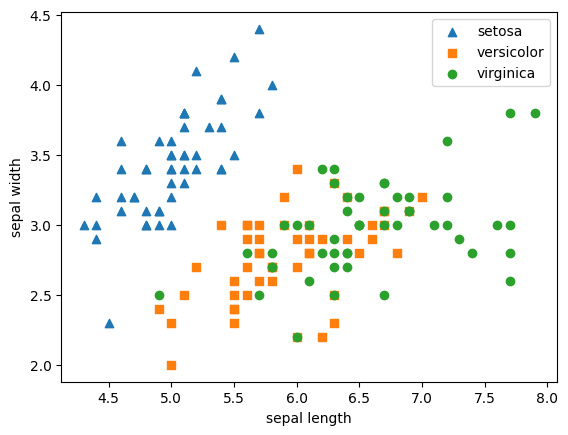

In [7]:
# setosa는 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = iris_df[iris_data.target==i]['sepal_length']
    y_data = iris_df[iris_data.target==i]['sepal_width']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

# 2.스케일링
- PCA는 여러 속성의 값을 연산해야 하므로 속성의 스케일에 영향을 받는다.
- 여러 속성을 PCA로 압축하기 전에 각 속성값을 동일한 스케일로 변환하는 것이 필요하다.

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
iris_df.iloc[:,:-1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
# target 값을 제외한 모든 속성 값을 StandardScaler를 이용해서 표준 정규 분포를 가지는 값들로 변환
scaler = StandardScaler()
scaler.fit(iris_df.iloc[:,:-1])
iris_scaled = scaler.transform(iris_df.iloc[:,:-1])

# 3.주성분 분석(PCA)

In [11]:
from sklearn.decomposition import PCA

In [12]:
# 변환할 차원의 수 : 2
pca = PCA(n_components=2)

In [13]:
iris_df.shape

(150, 5)

In [14]:
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)
print(iris_pca.shape)

(150, 2)


In [15]:
irispca_df = pd.DataFrame(iris_pca, columns=['pca_component_1', 'pca_component_2'])
irispca_df['target'] = iris_data.target
irispca_df.head()

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


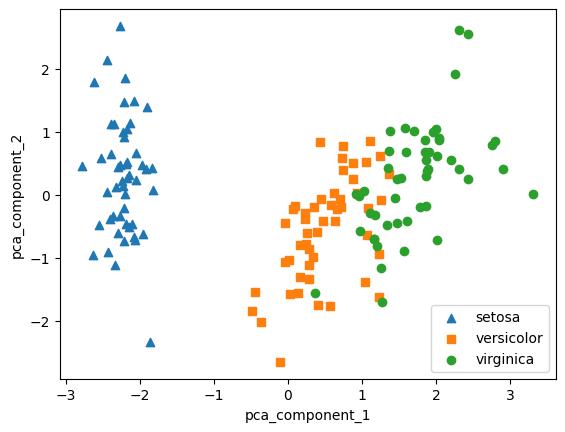

In [16]:

marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = irispca_df[irispca_df.target==i]['pca_component_1']
    y_data = irispca_df[irispca_df.target==i]['pca_component_2']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()

- versicolor와 virginica는 pca_component1 축을 기반으로 서로 겹치는 부분이 일부 존재하지만, 비교적 잘 구분됨.

In [17]:
# 전체 변동성에서 개별 PCA 컴포넌트별로 차지하는 변동성 비율을 제공
# 처음 두 개 주성분만으로도 원래 데이터의 95%
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


- 랜덤포레스트 모델과 비교해보기

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [20]:
rfc = RandomForestClassifier(random_state=1)
scores = cross_val_score(rfc, iris_data.data, iris_data.target, scoring='accuracy', cv=3)

print('원본 데이터 교차 검증 개별 정확도:', scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.98]
원본 데이터 평균 정확도: 0.9666666666666667


In [22]:
pca_X = irispca_df[['pca_component_1', 'pca_component_2']]
scores_pca = cross_val_score(rfc, pca_X, iris_data.target, scoring='accuracy', cv=3)

print('PCA 변환 데이터 교차 검증 개별 정확도:', scores_pca)
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

PCA 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도: 0.88


In [ ]:
# 4개의 속성이 2개의 변환 속성으로 감소하면서 예측 성능의 정확도가 원본 데이터 대비 약 8%
# 8% 정확도 하락은 비교적 큰 성능 수치의 감소지만, 4개의 속성이 2개로 속성 개수가 50% 감소한 것을 고려한다면 PCA 변환 후에도 원본 데이터의 특성을 상당 부분 유지하고 있음을 알 수 있음.


# 4.선형판별분석(LDA)
- 차원 축소 기법이자 분류 모델이다.
- PCA는 데이터의 분산을 기준으로 축을 찾는 반면, LDA는 클래스 분리를 극대화하는 축을 찾는다.

In [23]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [24]:
# n_components : 만들 선형 판별 축의 개수
lda = LinearDiscriminantAnalysis(n_components=2)

# LDA 지도학습
lda.fit(iris_scaled, iris_data.target)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",2
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [25]:
iris_lda = lda.transform(iris_scaled)

In [26]:
irislda_df = pd.DataFrame(iris_lda, columns=['lda_component_1', 'lda_component_2'])
irislda_df['target'] = iris_data.target
irislda_df.head()

,lda_component_1,lda_component_2,target
0,8.061800,-0.300421,0
1,7.128688,0.786660,0
2,7.489828,0.265384,0
3,6.813201,0.670631,0
4,8.132309,-0.514463,0


- PCA 와 다르게 LDA에서 유의해야 할 점은 LDA는 실제로는 PCA와 다르게 비지도학습이 아닌 지도학습이다.
- 즉, 클래스의 결정 값이 변환 시에 필요하다.

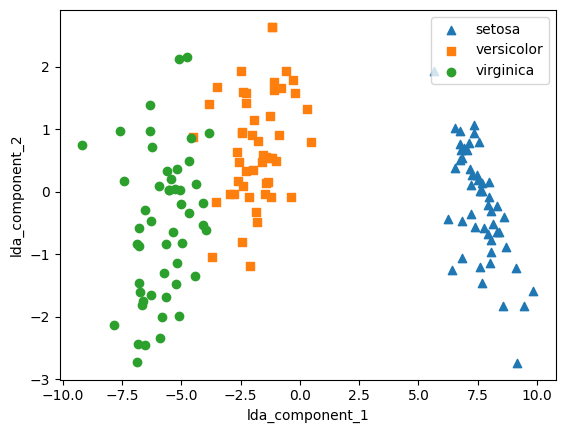

In [28]:
# setosa는 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = irislda_df[irislda_df.target==i]['lda_component_1']
    y_data = irislda_df[irislda_df.target==i]['lda_component_2']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend(loc='upper right')
plt.xlabel('lda_component_1')
plt.ylabel('lda_component_2')
plt.show()

# 5.특이값 분해(SVD)
- 모든 행렬에 적용 가능한 일반적인 차원 축소 기법
- PCA와 유사하며, 행렬을 세 개의 행렬로 분해하여 주요 패턴을 추출
- sklearn TruncatedSVD 클래스를 이용

In [29]:
from sklearn.decomposition import TruncatedSVD

In [ ]:
# 2개의 주요 component로 TruncatedSVC 변환
tsvd = TruncatedSVD(n_components=2)

# SVD 자체는 행렬을 분해하는 방법이라서 반드시 스케일링이 필요한 것은 아님. 하지만 변수들의 단위나 크기 차이가 크다면 스케일링 하는 것이 좋음.
tsvd.fit(iris_data.data)
iris_tsvd = tsvd.transform(iris_data.data)

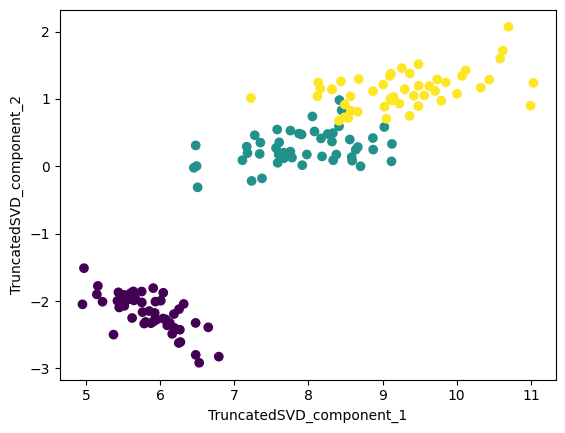

In [31]:
plt.scatter(x=iris_tsvd[:, 0],      # 첫번쨰 성분 값
            y=iris_tsvd[:, 1],      # 두번쨰 성분 값
            c=iris_data.target)
plt.xlabel('TruncatedSVD_component_1')
plt.ylabel('TruncatedSVD_component_2')
plt.show()

- pca와 비교

In [32]:
# Target값을 제외한 모든 속성 값을 StandardScaler를 이용해서 표준 정규 분포를 가지는 값들로 변환
scaler = StandardScaler()
scaler.fit(iris_df.iloc[:,:-1])
iris_scaled = scaler.transform(iris_df.iloc[:,:-1])

In [33]:
# 스케일된 데이터를 기반으로 TruncatedSVD 변환 수행
tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)

In [34]:
# 스케일된 데이터를 기반으로 PCA 변환 수행
pca = PCA(n_components=2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

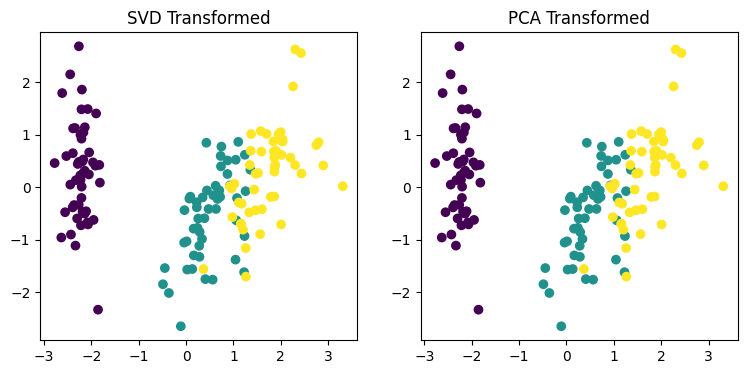

In [35]:
# TruncatedSVD 변환 데이터는 왼쪽, PCA 변환 데이터는 오른쪽
fig, (ax1, ax2) = plt.subplots(figsize=(9,4), ncols=2)

ax1.scatter(x=iris_tsvd[:, 0], y=iris_tsvd[:, 1], c=iris_data.target)
ax2.scatter(x=iris_pca[:, 0], y=iris_pca[:, 1], c=iris_data.target)
ax1.set_title('SVD Transformed')
ax2.set_title('PCA Transformed')

plt.show()

In [36]:
print((iris_pca - iris_tsvd).mean())                # 두 2D 좌표 차의 평균
print((pca.components_ - tsvd.components_).mean())  # 두 성분 벡터 차의 평균

# 두 결과값이 0에 가까우면 '두 방법이 만든 표현이 전체적으로 비슷하다'고 할 수 있음

6.805031075677685e-16
-3.903127820947816e-18
